# 05 - Collision Hotspots with k-Means Clustering

**This uses Module 5 of our course: unsupervised learning.**

Everything so far was supervised learning - we had labels (the severity) and
we trained a model to predict them.

Clustering is different. There are no labels. We just give the algorithm the
collision locations and it finds groups on its own.

**What we build here:** collision hotspot zones for the map.

We take the latitude and longitude of every collision and cluster them.
Each cluster is a danger zone. The app draws these on the map as coloured areas.

Our syllabus lists anomaly detection and segmentation as clustering uses.
Finding geographic danger zones is the same idea applied to road safety.


(22990, 19)


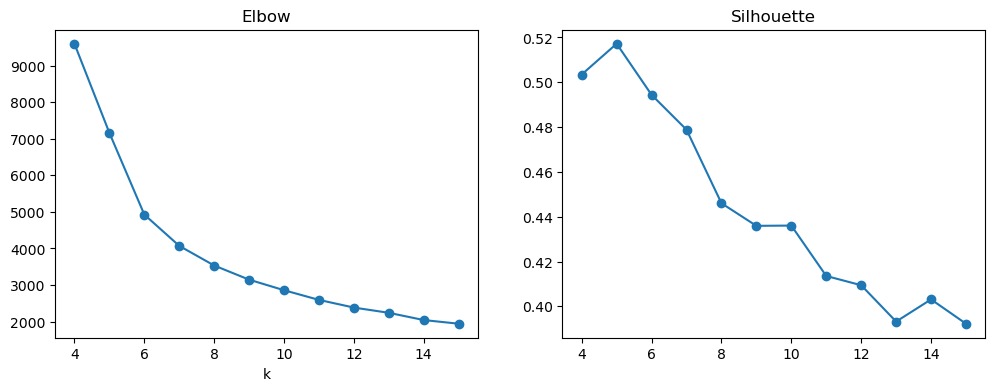

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1] / "ml" / "src"))
from config import CLEAN_FILE, ARTIFACTS_DIR, PROCESSED_DIR

df = pd.read_parquet(CLEAN_FILE)

# Focus on one region for demo (Manchester–Sheffield corridor example)
mask = (
    (df["latitude"].between(53.2, 53.6)) &
    (df["longitude"].between(-2.5, -1.3))
)
df_region = df[mask].copy()
print(df_region.shape)

coords = df_region[["latitude", "longitude"]].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Elbow + Silhouette
inertias = []
silhouettes = []
K_range = range(4, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(coords_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, "o-")
plt.title("Elbow")
plt.xlabel("k")
plt.subplot(1,2,2)
plt.plot(K_range, silhouettes, "o-")
plt.title("Silhouette")
plt.show()

In [ ]:
K = 8   #  choice
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_region["cluster"] = kmeans.fit_predict(coords_scaled)

# Per-cluster stats
cluster_stats = (
    df_region.groupby("cluster")
    .agg(
        total=("collision_severity", "size"),
        fatal=("collision_severity", lambda x: (x==1).sum()),
        serious=("collision_severity", lambda x: (x==2).sum()),
        lat=("latitude", "mean"),
        lon=("longitude", "mean"),
    )
    .reset_index()
)
cluster_stats["severe_rate"] = (
    (cluster_stats["fatal"] + cluster_stats["serious"]) / cluster_stats["total"]
)

# Risk bands 
def risk_band(rate):
    if rate > 0.30: return "high"
    elif rate > 0.20: return "moderate"
    else: return "low"

cluster_stats["risk_band"] = cluster_stats["severe_rate"].apply(risk_band)
print(cluster_stats)

# Save
joblib.dump(
    {"kmeans": kmeans, "scaler": scaler, "k": K},
    ARTIFACTS_DIR / "hotspot_kmeans.joblib"
)
cluster_stats.to_parquet(PROCESSED_DIR / "hotspot_clusters.parquet", index=False)

   cluster  total  fatal  serious        lat       lon  severe_rate risk_band
0        0   2173     39      758  53.547044 -1.487213     0.366774      high
1        1   2623     47      715  53.393416 -2.226700     0.290507  moderate
2        2   5732    101     1591  53.472436 -2.213936     0.295185  moderate
3        3   1350     20      328  53.247631 -1.459551     0.257778  moderate
4        4   3011     47      957  53.365244 -1.463050     0.333444      high
5        5   4101     76     1137  53.554349 -2.285967     0.295782  moderate
6        6   1505     30      326  53.275524 -2.184328     0.236545  moderate
7        7   2495     38      716  53.431580 -1.415965     0.302204      high



### Choice of k
We examined the elbow curve and silhouette scores for k = 4 to 14. We selected **k = 8** because:
- it sits near the elbow,
- silhouette score was competitive,
- eight zones remain readable on a city-scale map.

Three zones are too coarse; fifty zones become visual noise.

### What we store per cluster
- Total collisions  
- Fatal and Serious counts  
- Severe rate (Fatal + Serious) / Total  
- Cluster centre (lat, lon)  
- Risk band: low / moderate / high (thresholds set from the observed severe-rate distribution)

### Why k-Means and not DBSCAN?
k-Means is the algorithm taught in the module and produces stable, roughly balanced zones that are easy to colour on a map.  
DBSCAN would follow long thin road shapes better, but needs careful density-parameter tuning and can produce many tiny or noise clusters. For zone-level visualisation k-Means is adequate; we state this limitation honestly.

### Artifacts
- `hotspot_kmeans.joblib` — fitted k-Means + scaler (so the backend can transform a live point the same way)  
- `hotspot_clusters.parquet` — per-cluster statistics for the map and Insights page